In [1]:
pip install xgboost lightgbm scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import warnings
import gc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/duyem54/43-temp/data_43_temp.csv", skiprows=[1,2]) #trước mắt bỏ 2 dòng đầu cho dễ xử lí
print(f"temp_dataset: {df.shape}")

temp_dataset: (17526, 44)


---
# **Create Missing Data**

In [4]:
def generate_fixed_length_gaps(df_input, gap_days, num_gaps=10, seed=42, rows_per_day=8):
    """
    Tạo bộ dữ liệu missing với CÙNG MỘT độ dài gap cho tất cả các vị trí được chọn.
    Có tích hợp thuật toán chống đè (anti-overlap) để đảm bảo các gap không dính vào nhau.
    """
    df_temp = df_input.copy(deep=True)
    feature_columns = [col for col in df_temp.columns if col != "TimeVN"]
    
    # Đảm bảo format datetime để tìm đúng 1:00 AM
    ts = pd.to_datetime(df_temp['TimeVN'], format='mixed', dayfirst=True, errors='coerce')
    
    # Lấy ra vị trí (integer index) của các dòng có giờ = 1
    # Dùng np.where để lấy vị trí tuyệt đối, an toàn hơn loc khi thao tác
    daily_start_positions = np.where(ts.dt.hour == 1)[0].tolist()
    
    np.random.seed(seed)
    gap_rows = gap_days * rows_per_day
    
    # Dictionary lưu lại các index bị xóa để sau này tính RMSE, MAE
    missing_ground_truth = {col: [] for col in feature_columns}

    for col in feature_columns:
        col_idx = df_temp.columns.get_loc(col)
        
        # Chỉ giữ lại các vị trí bắt đầu mà khi cộng thêm gap_rows không vượt quá chiều dài data
        valid_starts = [pos for pos in daily_start_positions if pos + gap_rows <= len(df_temp)]
        
        available_starts = valid_starts.copy()
        
        for _ in range(num_gaps):
            if not available_starts:
                print(f"Cảnh báo: Không đủ khoảng trống để tạo đủ {num_gaps} gaps cho cột {col}")
                break
                
            # Chọn ngẫu nhiên 1 vị trí bắt đầu
            start_pos = np.random.choice(available_starts)
            end_pos = start_pos + gap_rows
            
            # Xóa dữ liệu (gán NaN)
            df_temp.iloc[start_pos:end_pos, col_idx] = np.nan
            
            # Lưu lại vị trí đã đục lỗ
            missing_ground_truth[col].extend(list(range(start_pos, end_pos)))
            
            # --- CƠ CHẾ CHỐNG ĐÈ (ANTI-OVERLAP) ---
            # Xóa bỏ các vị trí bắt đầu (start_pos) lân cận ra khỏi danh sách available_starts
            # Khoảng cách tối thiểu giữa 2 điểm bắt đầu phải lớn hơn chiều dài của gap
            available_starts = [pos for pos in available_starts if abs(pos - start_pos) > gap_rows]

    return df_temp, missing_ground_truth

# ================= TẠO 4 BỘ DATASET ĐỘC LẬP =================

# Giả sử 'df' là dataframe gốc của bạn
gap_scenarios = [1, 3, 5, 7]
missing_datasets = {}       # Chứa 4 dataframe đã bị đục lỗ
ground_truth_indices = {}   # Chứa vị trí các lỗ hổng để tính sai số sau này

for days in gap_scenarios:
    print(f"Đang tạo dataset cho kịch bản missing {days} ngày liên tục...")
    
    # Gọi hàm cho từng độ dài
    df_miss, truth_dict = generate_fixed_length_gaps(
        df_input=df, 
        gap_days=days, 
        num_gaps=10,   # Tùy chỉnh số lượng đoạn đứt gãy bạn muốn tạo
        seed=42,       # Giữ nguyên seed để kết quả random có thể tái lập được
        rows_per_day=8
    )
    
    # Lưu vào dictionary
    missing_datasets[f'gap_{days}d'] = df_miss
    ground_truth_indices[f'gap_{days}d'] = truth_dict
    
    total_nan = df_miss.isna().sum().sum()
    print(f"-> Hoàn tất! Tổng số NaN tạo ra: {total_nan}\n")

Đang tạo dataset cho kịch bản missing 1 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 3440

Đang tạo dataset cho kịch bản missing 3 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 10320

Đang tạo dataset cho kịch bản missing 5 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 17200

Đang tạo dataset cho kịch bản missing 7 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 24080



In [5]:
import pandas as pd
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

def split_by_hierarchical_stats(df, k=0.75, time_col='TimeVN'):
    """
    Chia nhóm dựa trên Mean và Std của Global Scores.
    k: Hệ số điều chỉnh độ rộng của nhóm Medium.
    """
    # Tách dữ liệu số
    df_numeric = df.select_dtypes(include=[np.number])
    
    # 1. Ensemble Correlation (Pearson + Spearman)
    corr_p = df_numeric.corr(method='pearson').abs()
    corr_s = df_numeric.corr(method='spearman').abs()
    corr = (corr_p + corr_s) / 2
    
    # 2. Tính Global Scores (Stability-adjusted Centrality)
    # Mean của từng hàng (bỏ tự tương quan đường chéo)
    mean_corr = corr.apply(lambda row: row.drop(row.name).mean(), axis=1)
    # Std của từng hàng (độ bất ổn định của tương quan)
    std_corr = corr.apply(lambda row: row.drop(row.name).std(), axis=1)
    
    # Global score: Ưu tiên tương quan cao và ổn định (std thấp)
    global_scores = mean_corr - (1.0 * std_corr) 

    # 3. TỰ ĐỘNG TÍNH NGƯỠNG THEO MEAN & STD
    mu = global_scores.mean()
    sigma = global_scores.std()
    
    low_thresh = mu - k * sigma
    high_thresh = mu + k * sigma
    
    # 4. Phân tách cột
    low_cols = global_scores[global_scores < low_thresh].index.tolist()
    high_cols = global_scores[global_scores >= high_thresh].index.tolist()
    med_cols = global_scores[(global_scores >= low_thresh) & (global_scores < high_thresh)].index.tolist()
    
    # 5. Distance Matrix & Linkage (Phục vụ vẽ Dendrogram nếu cần)
    dist_matrix = 1 - corr.fillna(0)
    dist_vec = squareform(dist_matrix, checks=False)
    linkage_matrix = hierarchy.ward(dist_vec)
    
    # Trả kết quả
    time_list = [time_col] if time_col in df.columns else []
    return (df[time_list + low_cols], 
            df[time_list + med_cols], 
            df[time_list + high_cols], 
            global_scores, low_thresh, high_thresh)

def plot_correlation_split_v2(global_scores, low_thresh, high_thresh):
    scores_sorted = global_scores.sort_values()
    features = scores_sorted.index
    values = scores_sorted.values
    mu = global_scores.mean()

    # Màu sắc cho 3 nhóm
    colors = ['#87CEFA' if v < low_thresh else '#FF6347' if v >= high_thresh else '#FFB6C1' for v in values]

    plt.figure(figsize=(13, 6))
    bars = plt.bar(features, values, color=colors, edgecolor='black', alpha=0.7)

    # Vẽ đường Threshold và Mean
    plt.axhline(y=low_thresh, color='blue', linestyle='--', label=f'Low Thresh (μ - kσ): {low_thresh:.3f}')
    plt.axhline(y=high_thresh, color='red', linestyle='--', label=f'High Thresh (μ + kσ): {high_thresh:.3f}')
    plt.axhline(y=mu, color='green', linestyle='-', alpha=0.5, label=f'Mean (μ): {mu:.3f}')

    plt.title('Feature Classification by Statistical Thresholds', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Thêm text số lượng vào biểu đồ
    low_n = (values < low_thresh).sum()
    med_n = ((values >= low_thresh) & (values < high_thresh)).sum()
    high_n = (values >= high_thresh).sum()
    
    plt.text(len(values), low_thresh, f' n={low_n}', color='blue', fontweight='bold')
    plt.text(len(values), high_thresh, f' n={high_n}', color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

--- Thống kê phân bổ ---
Low (dưới 0.507): 9 features
Medium: 23 features
High (trên 0.637): 11 features


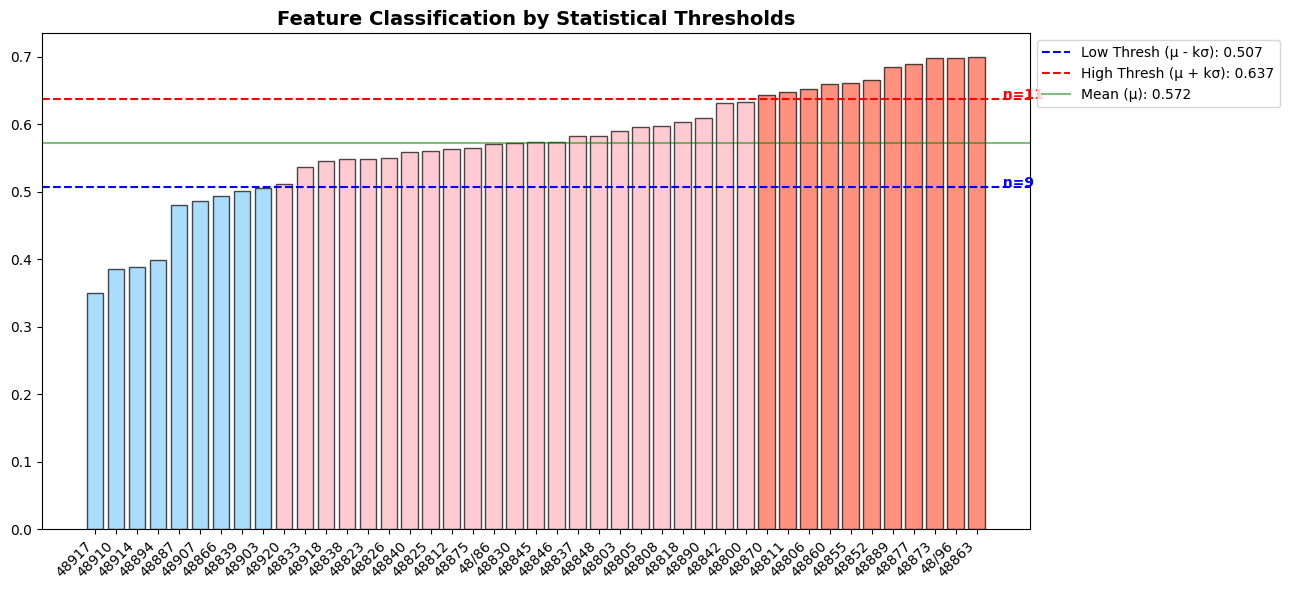

In [6]:
# k=0.75 là mức chia khá cân bằng. 
# Nếu muốn nhóm Medium hẹp lại (ít biến hơn), hãy giảm k xuống (vớ dụ k=0.5).
df_low, df_med, df_high, scores, lt, ht = split_by_hierarchical_stats(df, k=0.75)

print(f"--- Thống kê phân bổ ---")
print(f"Low (dưới {lt:.3f}): {len(df_low.columns) - 1} features")
print(f"Medium: {len(df_med.columns) - 1} features")
print(f"High (trên {ht:.3f}): {len(df_high.columns) - 1} features")

plot_correlation_split_v2(scores, lt, ht)

---
# **Models**

In [7]:
import time
import pandas as pd
import numpy as np
import gc
import os
from tqdm.auto import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy
from sklearn.base import clone as sk_clone

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 0. TẠO GAP & CHIA NHÓM
# ==========================================
def generate_fixed_length_gaps(df_input, gap_days, num_gaps=10, seed=42, rows_per_day=8):
    df_temp = df_input.copy(deep=True)
    feature_columns = [col for col in df_temp.columns if col != "TimeVN"]
    ts = pd.to_datetime(df_temp['TimeVN'], format='mixed', dayfirst=True, errors='coerce')
    daily_start_positions = np.where(ts.dt.hour == 1)[0].tolist()

    np.random.seed(seed)
    gap_rows = gap_days * rows_per_day
    missing_ground_truth = {col: [] for col in feature_columns}

    for col in feature_columns:
        col_idx      = df_temp.columns.get_loc(col)
        valid_starts = [pos for pos in daily_start_positions
                        if pos + gap_rows <= len(df_temp)]
        available_starts = valid_starts.copy()

        for _ in range(num_gaps):
            if not available_starts:
                print(f"Cảnh báo: Không đủ khoảng trống cho {col}")
                break
            start_pos = np.random.choice(available_starts)
            end_pos   = start_pos + gap_rows
            df_temp.iloc[start_pos:end_pos, col_idx] = np.nan
            missing_ground_truth[col].extend(list(range(start_pos, end_pos)))
            available_starts = [p for p in available_starts
                                 if abs(p - start_pos) > gap_rows]
    return df_temp, missing_ground_truth

def split_by_hierarchical_stats(df, k=0.75, time_col='TimeVN'):
    df_numeric    = df.select_dtypes(include=[np.number])
    corr_p        = df_numeric.corr(method='pearson').abs()
    corr_s        = df_numeric.corr(method='spearman').abs()
    corr          = (corr_p + corr_s) / 2
    mean_corr     = corr.apply(lambda row: row.drop(row.name).mean(), axis=1)
    std_corr      = corr.apply(lambda row: row.drop(row.name).std(),  axis=1)
    global_scores = mean_corr - (1.0 * std_corr)

    mu, sigma   = global_scores.mean(), global_scores.std()
    low_thresh  = mu - k * sigma
    high_thresh = mu + k * sigma

    low_cols  = global_scores[global_scores <  low_thresh].index.tolist()
    med_cols  = global_scores[(global_scores >= low_thresh) &
                               (global_scores <  high_thresh)].index.tolist()
    high_cols = global_scores[global_scores >= high_thresh].index.tolist()

    time_list = [time_col] if time_col in df.columns else []
    return (df[time_list + low_cols],
            df[time_list + med_cols],
            df[time_list + high_cols],
            global_scores, low_thresh, high_thresh)

# ==========================================
# 1. SEED: WEIGHTED LGBM (FAST VERSION)
# ==========================================
def get_weighted_lgbm_seed(df_miss):
    """
    Dùng linear interpolation cho các cột khác làm feature thay vì lag features 
    để tối ưu tốc độ. Giữ n_estimators=50.
    """
    df_num      = df_miss.select_dtypes(include=[np.number]).copy().astype('float32')
    df_features = (df_num.interpolate(method='linear', limit_direction='both')
                         .ffill().bfill().fillna(0))
    df_filled   = df_num.copy()
    target_cols = df_num.columns.tolist()

    for col in tqdm(target_cols, desc="[SICE] Seed weighted-LGBM", leave=False):
        s = df_num[col].reset_index(drop=True)
        if not s.isna().any():
            continue

        features = [c for c in target_cols if c != col]
        if not features:
            continue

        is_missing  = s.isna().astype(int)
        diff        = is_missing.diff().fillna(is_missing)
        starts_idx  = np.where(diff == 1)[0]
        ends_idx    = np.where(diff == -1)[0]
        if len(starts_idx) > len(ends_idx):
            ends_idx = np.append(ends_idx, len(s))

        for st, en in zip(starts_idx, ends_idx):
            valid_before = np.where(~s.iloc[:st].isna())[0]
            valid_after  = np.where(~s.iloc[en:].isna())[0] + en
            lb, la = len(valid_before), len(valid_after)
            if lb == 0 and la == 0:
                continue

            alpha  = lb / (lb + la)
            X_test = df_features.iloc[st:en][features].values
            y_b, y_a = np.zeros(en - st), np.zeros(en - st)

            # Khởi tạo mô hình gọn nhẹ
            def _new_lgbm():
                return LGBMRegressor(n_estimators=50, n_jobs=-1, random_state=42, verbose=-1)

            if lb > 0:
                m = _new_lgbm()
                m.fit(df_features.iloc[valid_before][features].values, s.iloc[valid_before].values)
                y_b = m.predict(X_test)
            if la > 0:
                m = _new_lgbm()
                m.fit(df_features.iloc[valid_after][features].values, s.iloc[valid_after].values)
                y_a = m.predict(X_test)

            df_filled.iloc[st:en, df_filled.columns.get_loc(col)] = (
                y_a if lb == 0 else (y_b if la == 0 else alpha * y_b + (1 - alpha) * y_a)
            )
            
    return df_filled

# ==========================================
# 2. SICE OVR — SAFE VERSION (sk_clone)
# ==========================================
def run_sice_lgbm(df_miss, df_seed):
    df_num      = df_miss.select_dtypes(include=[np.number]).astype('float32')
    target_cols = df_num.columns.tolist()
    working     = df_seed[target_cols].copy().astype('float64')

    _base_model = LGBMRegressor(n_estimators=50, n_jobs=-1, random_state=42, verbose=-1)

    for target in tqdm(target_cols, desc="[SICE] OVR-LGBM", leave=False):
        m_idx = df_num[target].isna()
        if not m_idx.any():
            continue

        pred_cols = [c for c in target_cols if c != target]
        model = sk_clone(_base_model) # Tránh state leak

        model.fit(working.loc[~m_idx, pred_cols].values,
                  df_num.loc[~m_idx, target].values.astype('float64'))
        
        working.loc[m_idx, target] = model.predict(working.loc[m_idx, pred_cols].values)

    return working

# ==========================================
# 3. MICE: BayesianRidge
# ==========================================
def run_mice_imputation(df_miss, max_iter=20, random_state=42):
    num_cols    = df_miss.select_dtypes(include=[np.number]).columns.tolist()
    df_miss_num = df_miss[num_cols].copy().astype('float64')
    imputer     = IterativeImputer(estimator=BayesianRidge(),
                                   max_iter=max_iter,
                                   random_state=random_state)
    return pd.DataFrame(imputer.fit_transform(df_miss_num),
                        columns=num_cols, index=df_miss_num.index)

# ==========================================
# 4. METRICS
# ==========================================
def get_final_metrics(df_orig, df_imp, df_miss):
    stats = []
    skip  = {'TimeVN', 'Time', 'Date'}

    for col in df_miss.columns:
        if col in skip or col not in df_orig.columns or col not in df_imp.columns:
            continue

        miss_col = df_miss[col].reindex(df_orig.index)
        imp_col  = df_imp[col].reindex(df_orig.index)
        mask     = miss_col.isna() & df_orig[col].notna()

        yt = df_orig.loc[mask, col].values.astype(float)
        yp = imp_col.loc[mask].values.astype(float)
        ok = ~np.isnan(yp)
        yt, yp = yt[ok], yp[ok]
        if len(yt) < 2:
            continue

        rng = float(np.nanmax(df_orig[col])) - float(np.nanmin(df_orig[col]))
        rng = rng if rng > 0 else 1.0

        stats.append({
            "Station": col,
            "NSE":  1 - np.sum((yt-yp)**2) / (np.sum((yt-np.mean(yt))**2) + 1e-9),
            "R2":   r2_score(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "MAE":  np.mean(np.abs(yt - yp)),
            "Sim":  np.mean(1 / (1 + np.abs(yp - yt) / rng)),
        })
    return pd.DataFrame(stats)

# ==========================================
# 5. PIPELINE CHÍNH
# ==========================================
METHOD_NAME   = "MICE_vs_SICE_FastSafe"
gap_scenarios = [1, 3, 5, 7]
K_FACTOR      = 0.75
all_summary   = []

ROOT_SAVE_DIR = f"Results_{METHOD_NAME}"
os.makedirs(ROOT_SAVE_DIR, exist_ok=True)

print("🚀 MICE (BayesianRidge, no seed)  vs  SICE (Weighted LGBM seed + LGBM OVR)")

for days in gap_scenarios:
    print(f"\n{'='*30} GAP {days}D {'='*30}")

    df_miss_all, _ = generate_fixed_length_gaps(df, gap_days=days, seed=42)
    df_l, df_m, df_h, global_scores, lt, ht = split_by_hierarchical_stats(
        df_miss_all, k=K_FACTOR)
    print(f"Ngưỡng: LOW < {lt:.3f} | MED [{lt:.3f}–{ht:.3f}] | HIGH ≥ {ht:.3f}")

    for level_name, df_grp in [('LOW', df_l), ('MED', df_m), ('HIGH', df_h)]:
        actual_cols = [c for c in df_grp.columns if c != 'TimeVN']
        if not actual_cols:
            print(f"  ⚠ {level_name} trống, bỏ qua")
            continue

        df_grp = df_grp.copy()
        for c in actual_cols:
            df_grp[c] = pd.to_numeric(df_grp[c], errors='coerce')

        # ── MICE ──────────────────────────────────────────
        try:
            t0          = time.time()
            df_imp_mice = run_mice_imputation(df_grp)
            t_mice      = time.time() - t0

            m = get_final_metrics(df, df_imp_mice, df_grp)
            if not m.empty:
                s = m.mean(numeric_only=True)
                all_summary.append({
                    'Gap': f"{days}D", 'Level': level_name, 'Model': 'MICE-Bayes',
                    'NSE': s['NSE'], 'R2': s['R2'], 'RMSE': s['RMSE'],
                    'MAE': s['MAE'], 'Sim': s['Sim'], 'Time (s)': t_mice,
                })
        except Exception as e:
            print(f"  ✗ MICE [{level_name}]: {e}")

        # ── SICE ──────────────────────────────────────────
        try:
            t0          = time.time()
            seed_sice   = get_weighted_lgbm_seed(df_grp)
            df_imp_sice = run_sice_lgbm(df_grp, seed_sice)
            t_sice      = time.time() - t0

            m = get_final_metrics(df, df_imp_sice, df_grp)
            if not m.empty:
                s = m.mean(numeric_only=True)
                all_summary.append({
                    'Gap': f"{days}D", 'Level': level_name, 'Model': 'SICE-LGBM',
                    'NSE': s['NSE'], 'R2': s['R2'], 'RMSE': s['RMSE'],
                    'MAE': s['MAE'], 'Sim': s['Sim'], 'Time (s)': t_sice,
                })
        except Exception as e:
            print(f"  ✗ SICE [{level_name}]: {e}")

        gc.collect()

# ==========================================
# 6. KẾT QUẢ
# ==========================================
summary_df  = pd.DataFrame(all_summary)
metric_cols = ['NSE', 'R2', 'RMSE', 'MAE', 'Sim', 'Time (s)']

for days in gap_scenarios:
    sub = summary_df[summary_df['Gap'] == f"{days}D"]
    if sub.empty:
        continue
    pivot = sub.pivot(index='Level', columns='Model', values=metric_cols)
    print(f"\n📊 {days}D:")
    display(pivot.style.format(precision=4))

avg = (summary_df
       .groupby(['Level', 'Model'])[metric_cols]
       .mean()
       .unstack('Model'))                    

print("\n🏆 Trung bình tổng hợp:")
display(avg.style.format(precision=4)
           .background_gradient(cmap='RdYlGn',
                                subset=[('NSE', 'MICE-Bayes'),
                                        ('NSE', 'SICE-LGBM')]))

🚀 MICE (BayesianRidge, no seed)  vs  SICE (Weighted LGBM seed + LGBM OVR)

============================== GAP 1D ==============================
Ngưỡng: LOW < 0.507 | MED [0.507–0.637] | HIGH ≥ 0.637


[SICE] Seed weighted-LGBM:   0%|          | 0/9 [00:00<?, ?it/s]

[SICE] OVR-LGBM:   0%|          | 0/9 [00:00<?, ?it/s]

[SICE] Seed weighted-LGBM:   0%|          | 0/23 [00:00<?, ?it/s]

[SICE] OVR-LGBM:   0%|          | 0/23 [00:00<?, ?it/s]

...


📊 1D:



📊 3D:



📊 5D:



📊 7D:



🏆 Trung bình tổng hợp:
